In [2]:
%run "01 Functions.ipynb"

72019
51863


## EDA

In [8]:
merged_df.value_counts("Category")

Category
house         33560
condo         27266
land           7959
commercial     2930
apartment       304
dtype: int64

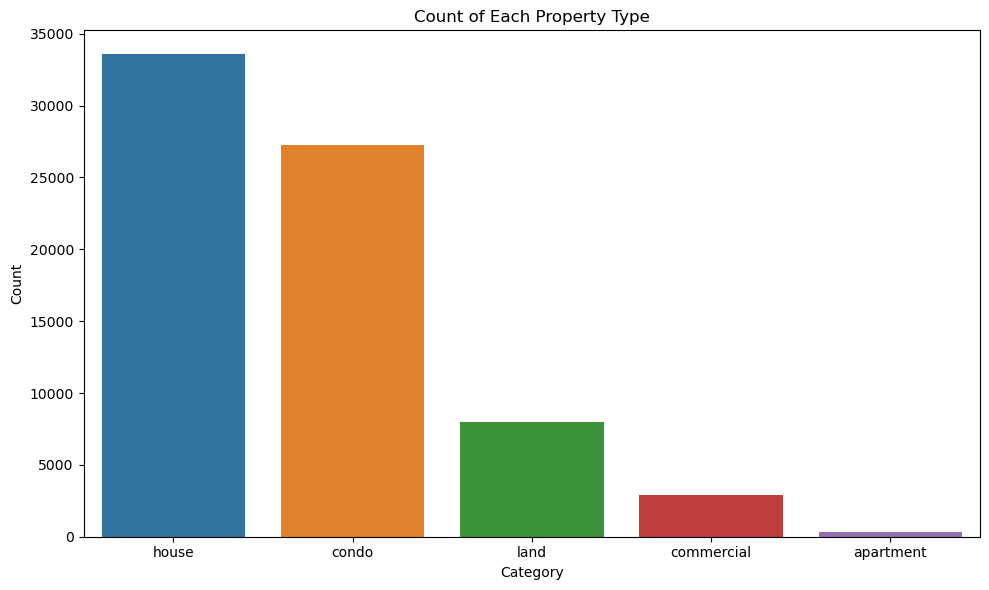

In [18]:
import seaborn as sns
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.countplot(data=merged_df, x="Category")
plt.title(f'Count of Each Property Type')
plt.xlabel("Category")
plt.ylabel('Count')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

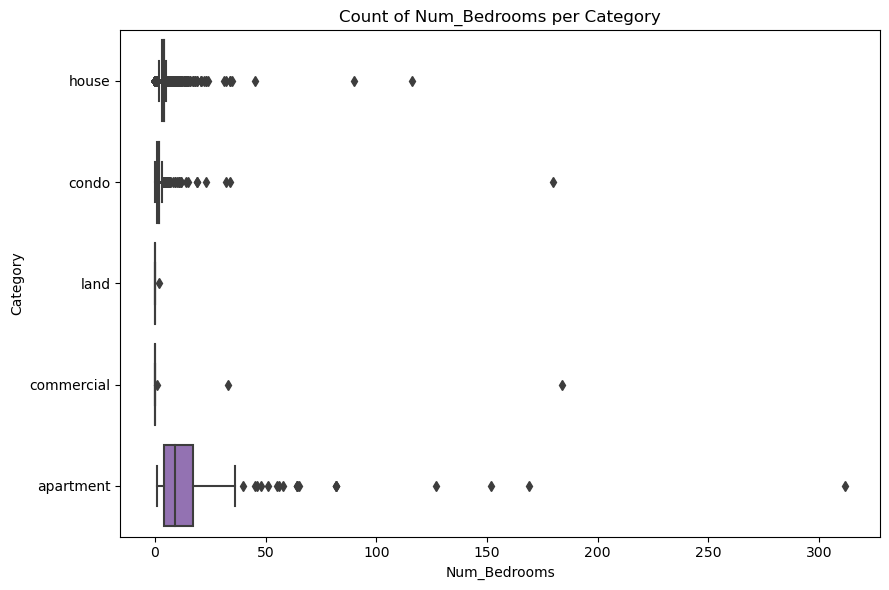

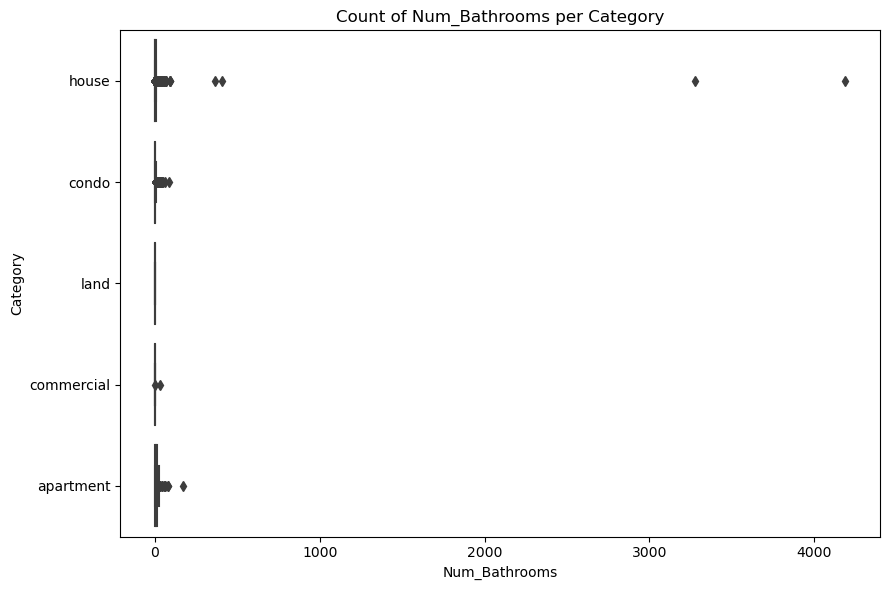

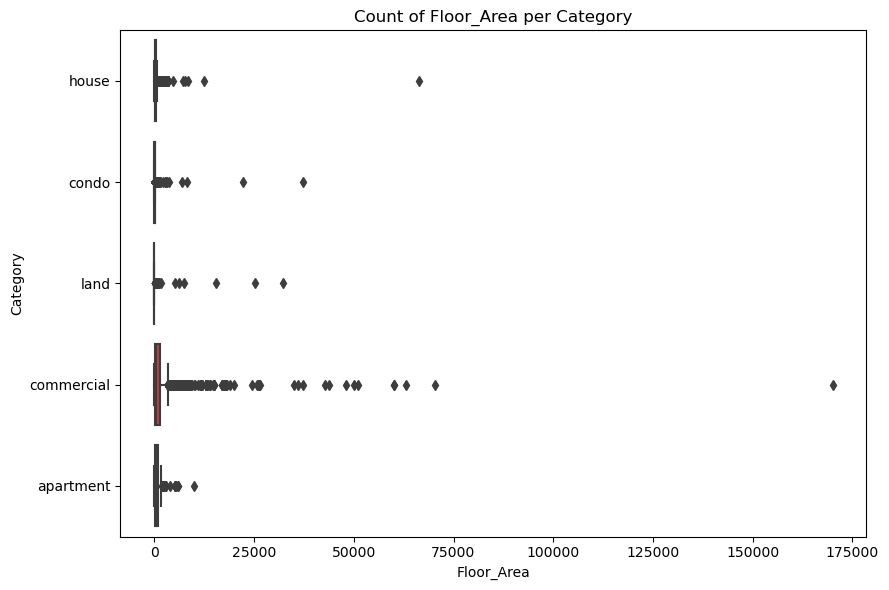

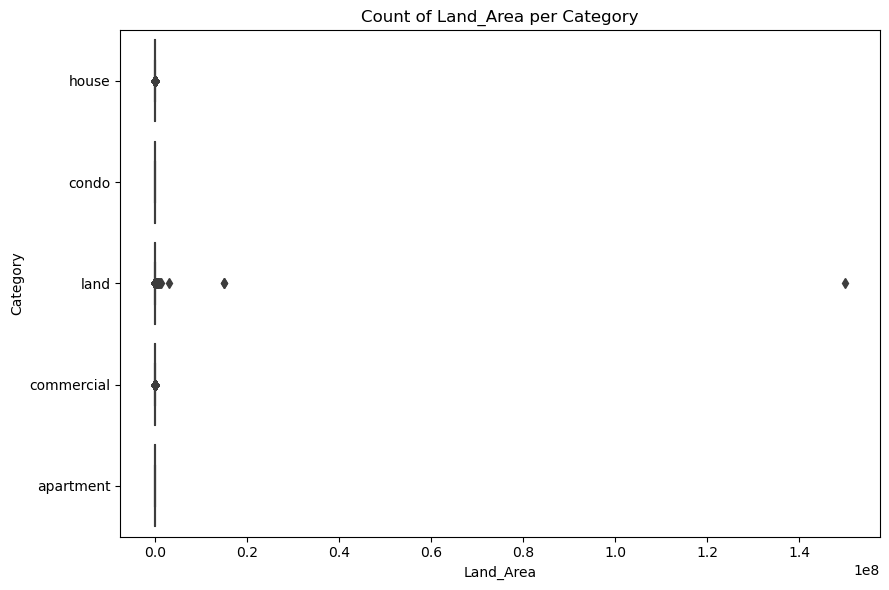

In [ ]:
def create_boxplots_by_property_type(df, features, property_type_column):
    for feature in features:
        plt.figure(figsize=(9, 6))  # Adjust figure size as needed
        sns.boxplot(data=df, y=property_type_column, x=feature, orient='h')
        plt.title(f'Count of {feature} per {property_type_column}')
        plt.tight_layout()
        
        filename = os.path.join("Graphics", f'boxplot_{feature}.png')
        plt.savefig(filename)
        plt.show()
        plt.close()

create_boxplots_by_property_type(merged_df, value_cols, "Category")

71539


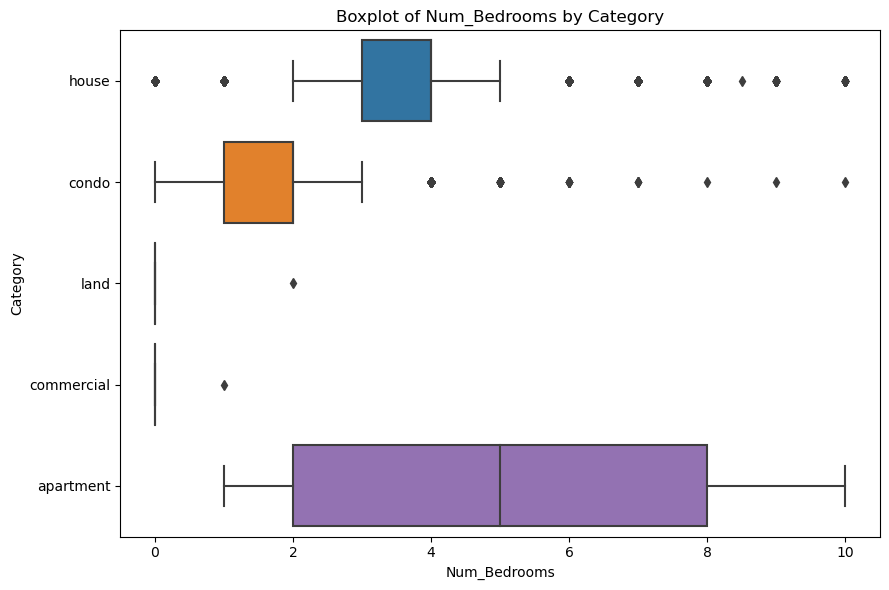

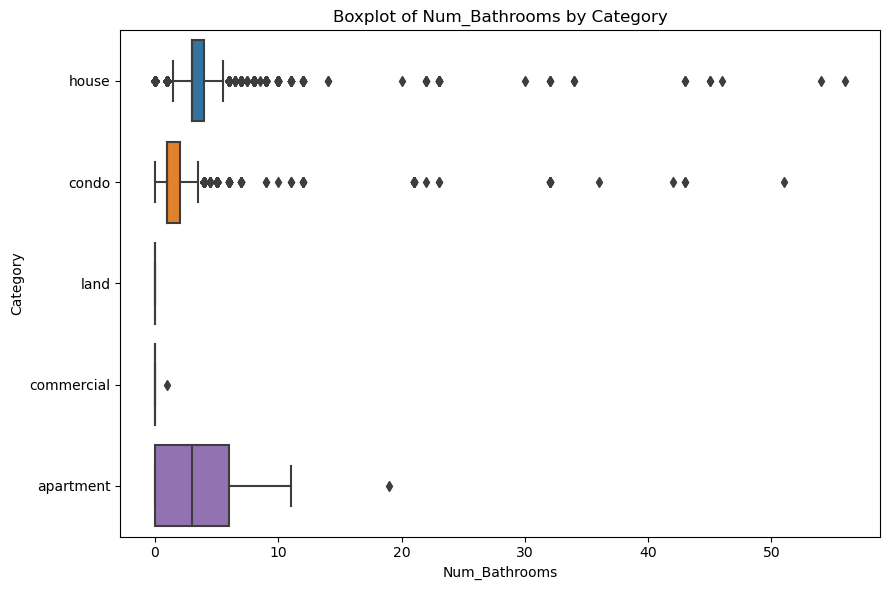

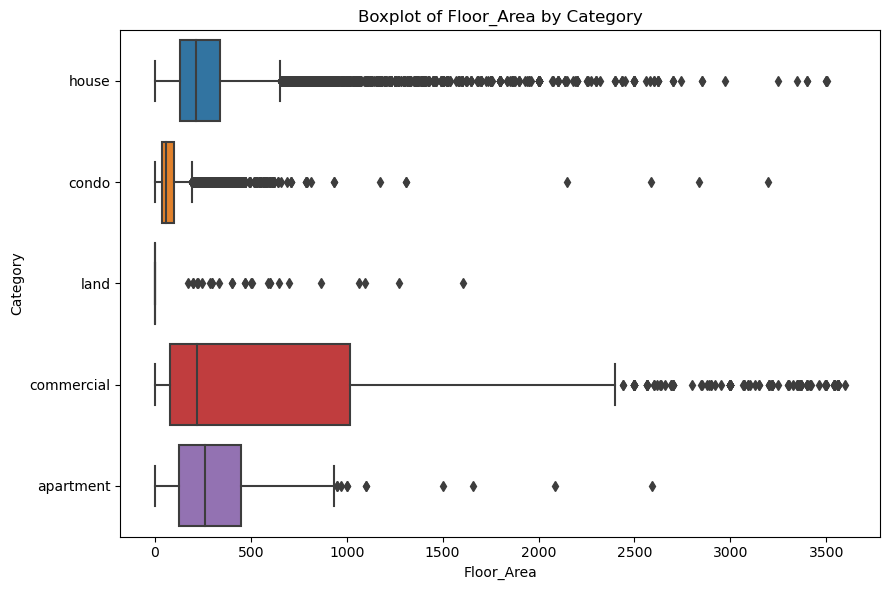

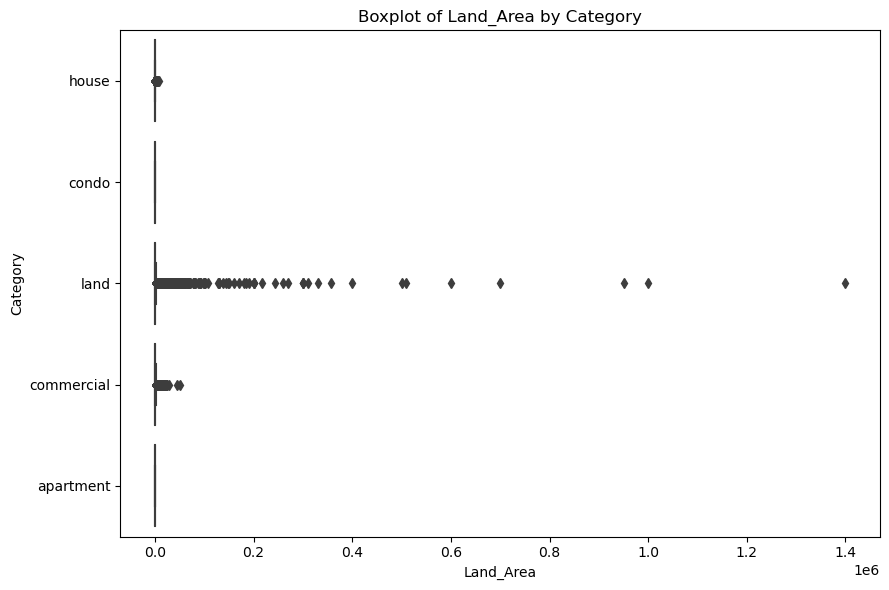

In [36]:
def remove_outliers_zscore(df, features, threshold=3):
    """Removes outliers based on Z-score for multiple features."""
    df_filtered = df.copy()
    z_scores = {}

    for feature in features:
        z_scores[feature] = (df_filtered[feature] - df_filtered[feature].mean()) / df_filtered[feature].std()

    outlier_mask = np.zeros(len(df_filtered), dtype=bool)

    for feature in features:
        outlier_mask = outlier_mask | (np.abs(z_scores[feature]) > threshold)

    df_filtered = df_filtered[~outlier_mask]
    return df_filtered

df_cleaned = remove_outliers_zscore(merged_df, value_cols)
print(len(df_cleaned))
create_boxplots_by_property_type(df_cleaned, value_cols, "Category")

61661
Category
house         28973
condo         27121
land           4097
commercial     1359
apartment       111
dtype: int64


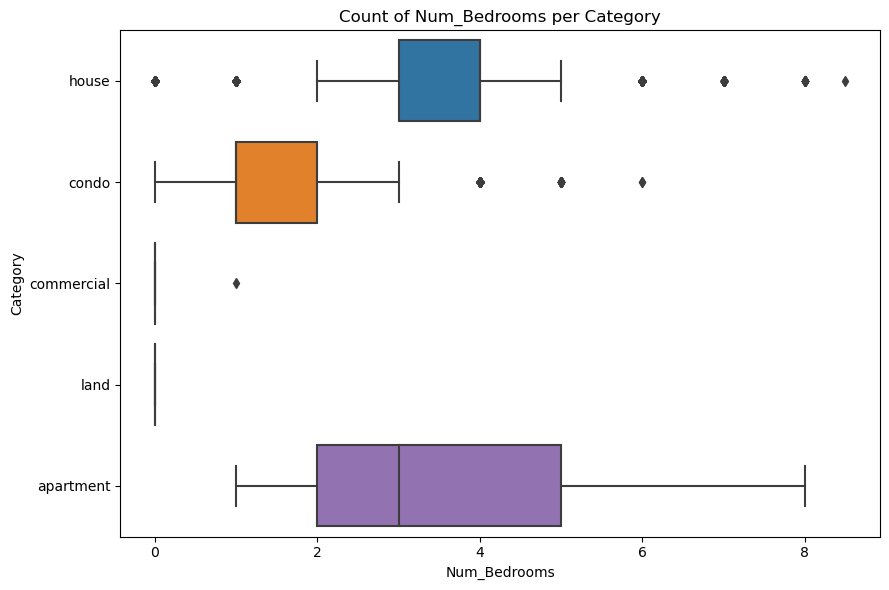

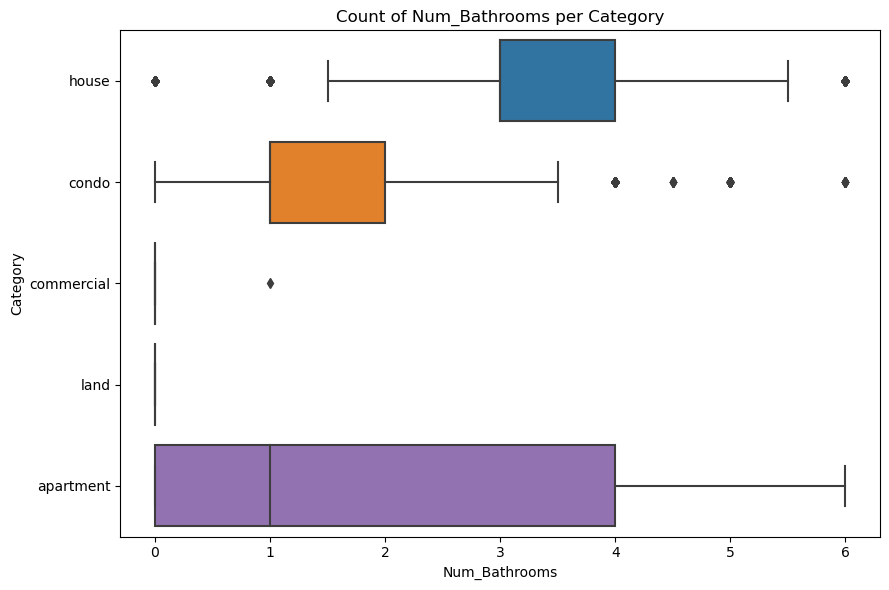

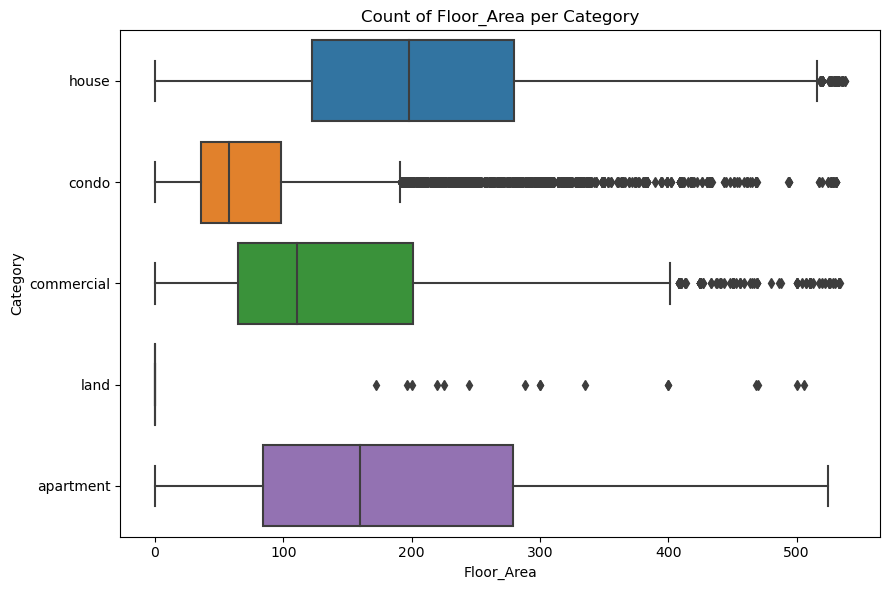

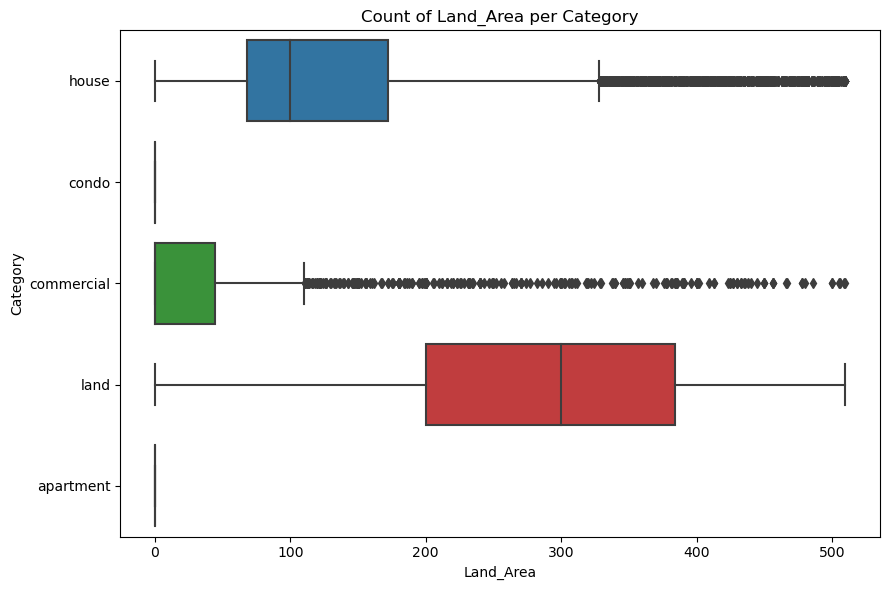

In [42]:
def remove_outliers_iqr(df, features, multiplier=1.5):
    df_filtered = df.copy()
    outlier_mask = np.zeros(len(df_filtered), dtype=bool)

    for feature in features:
        Q1 = df_filtered[feature].quantile(0.25)
        Q3 = df_filtered[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        outlier_mask = outlier_mask | ((df_filtered[feature] < lower_bound) | (df_filtered[feature] > upper_bound))

    df_filtered = df_filtered[~outlier_mask]
    return df_filtered

df_cleaned = remove_outliers_iqr(merged_df, value_cols)
print(len(df_cleaned))
print(df_cleaned.value_counts("Category"))
create_boxplots_by_property_type(df_cleaned, value_cols, "Category")

In [44]:
df = df_cleaned
df[(df[["Title", "Price", "Category"]].duplicated(keep=False)) & (~df["Title"].isna())].sort_values("Title")

,Unnamed: 0,Location,URL,SKU,Title,Price,Category,Num_Bedrooms,Num_Bathrooms,Floor_Area,...,PROVINCE / LGU,employment_generation,financial_deepening,local_economy_growth,local_economy_size,presence_of_business_and_professional_organizations,safety_compliant_business,ATMHubName,ATMHubDist,ATMCount
14842,14842,"Poblacion, Makati",https://www.lamudi.com.ph/projects/antel-spa-a...,CD64EFFFCB87D32PH,Good Deal Studio Unit at Antel Spa Residences...,4100000.0,condo,1.0,1.0,23.1,...,Makati,1.0473,0.6374,0.2141,1.3742,0.0185,0.7263,377,0.357731,15
14811,14811,"Poblacion, Makati",https://www.lamudi.com.ph/projects/antel-spa-a...,CD64F0018F6F83EPH,Good Deal Studio Unit at Antel Spa Residences...,4100000.0,condo,1.0,1.0,23.1,...,Makati,1.0473,0.6374,0.2141,1.3742,0.0185,0.7263,377,0.357731,15
19088,19088,"Pio Del Pilar, Makati",https://www.lamudi.com.ph/buy/metro-manila/mak...,CD64F13DBFE87E2PH,1 Bedroom Condo Unit at 100 West Makati For Sale,9700000.0,condo,1.0,1.0,48.0,...,Makati,1.0473,0.6374,0.2141,1.3742,0.0185,0.7263,976,0.219305,40
19296,19296,"Pio Del Pilar, Makati",https://www.lamudi.com.ph/buy/metro-manila/mak...,CD6180E6B46E148PH,1 Bedroom Condo Unit at 100 West Makati For Sale,9700000.0,condo,1.0,1.0,48.0,...,Makati,1.0473,0.6374,0.2141,1.3742,0.0185,0.7263,935,0.266428,31
37364,37364,"Ortigas CBD, Pasig",https://www.lamudi.com.ph/buy/metro-manila/pas...,CD651E6F1E4DA05PH,1 Bedroom Condominium Unit for Sale at The Sap...,10638759.0,condo,1.0,1.0,37.0,...,Pasig,0.4337,0.9254,0.1972,0.3283,0.2529,0.4976,818,0.226791,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12127,12127,"Talon Dos, Las Piñas",https://www.lamudi.com.ph/projects/bf-resort-v...,HO6421E5694085FPH,modern design house and lot in bf resort,20000000.0,house,2.0,2.0,260.0,...,Las Pinas,0.1593,0.2592,0.1281,0.0403,0.0000,0.2772,658,0.640053,1
11994,11994,"Pilar, Las Piñas",https://www.lamudi.com.ph/projects/pilar-villa...,HO633E44DC82E54PH,newly built bungalow house and lot with modern...,15000000.0,house,5.0,5.0,252.0,...,Las Pinas,0.1593,0.2592,0.1281,0.0403,0.0000,0.2772,1013,0.998288,1
11866,11866,"Pilar, Las Piñas",https://www.lamudi.com.ph/projects/pilar-villa...,HO62D4CDB88F274PH,newly built bungalow house and lot with modern...,15000000.0,house,5.0,5.0,252.0,...,Las Pinas,0.1593,0.2592,0.1281,0.0403,0.0000,0.2772,1013,0.998288,1
9631,9631,"Pilar, Las Piñas",https://www.lamudi.com.ph/projects/pilar-villa...,HO64E84C9CBEA66PH,spacious newly built bungalow house in pilar v...,12500000.0,house,3.0,3.0,150.0,...,Las Pinas,0.1593,0.2592,0.1281,0.0403,0.0000,0.2772,1013,0.998288,1


In [5]:
to_drop = merged_df[(merged_df[["Title", "Price", "Category"]].duplicated()) & (~merged_df["Title"].isna())].index
merged_df_edited = merged_df.drop(index=to_drop)

<AxesSubplot:>

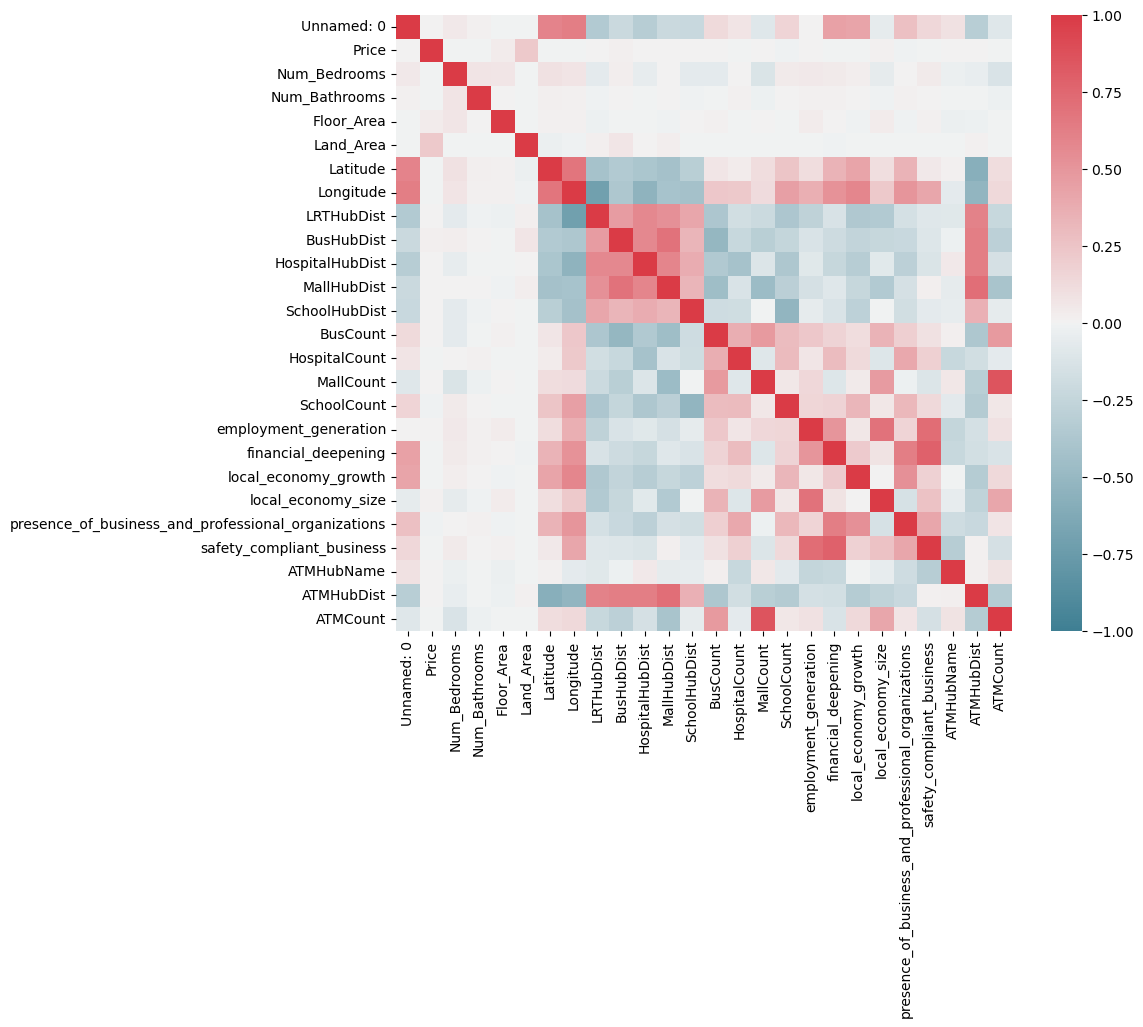

In [7]:
f, ax = plt.subplots(figsize=(10, 8))
corr = merged_df.corr()
sns.heatmap(corr,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1.0, vmax=1.0,
    square=True, ax=ax)